In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# stats packages
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols, mixedlm
from statsmodels.stats.anova import AnovaRM


# set save loaction for figures
fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [2]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [3]:
%run env_tom.py
%run run.py connect

2024-09-24 13:15:03,365::INFO::settings.py::Setting loglevel to INFO
2024-09-24 13:15:03,366::INFO::settings.py::Setting stores to {}
2024-09-24 13:15:03,366::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-09-24 13:15:03,367::INFO::settings.py::Setting database.misc.create_tables to True
2024-09-24 13:15:03,367::INFO::settings.py::Setting enable_python_native_blobs to True
2024-09-24 13:15:03,368::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-09-24 13:15:03,368::INFO::settings.py::Setting database.user to thomas
2024-09-24 13:15:03,368::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-09-24 13:15:03,766::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-09-24 13:15:03,835::INFO::table.py::could not log event in table ~log
2024-09-24 13:15:04,130::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
from vr4mice.analysis import regression
vdf.get_rc_params()


In [5]:
list_tasks = []
for d in vr4mice.Metadata().fetch("dataset", "session_label", as_dict=True):
    if d["session_label"] == "ar_shape_discrim_occluders":
        list_tasks.append(d ["dataset"])
    
    

In [6]:
list_tasks

['Uguisu_2024-09-13_1',
 'Uguisu_2024-09-16_1',
 'Uguisu_2024-09-17_1',
 'Uguisu_2024-09-18_1',
 'Uguisu_2024-09-19_1',
 'Vegavis_2024-09-17_1',
 'Vegavis_2024-09-18_1',
 'Vegavis_2024-09-18_2',
 'Vegavis_2024-09-19_1',
 'Wiwaxia_2024-09-23_1']

In [8]:
def tranform_dlc_centers_to_rig_coords(head_center_x, head_center_y):
    cropped_image=[0, 530, 0, 510]
    unity_arena_size=[-9, 9, -10, -2]
    x = np.interp(np.array(head_center_x, np.float16),
                [cropped_image[0], cropped_image[1]],
                [unity_arena_size[0], unity_arena_size[1]],
            )
    y = np.interp(np.array(head_center_y, np.float16),
                [cropped_image[2], cropped_image[3]],
                [unity_arena_size[2], unity_arena_size[3]],
            )
    x = np.interp(x, [-9, 9], [-27, 27])
    y = np.interp(y, [-10, -2], [-27, 27])
    return(x, y)
    

def get_all_in_list(data_set_list, training_stage="dual_occluder"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        df = base_analysis.DataFrame().get_data(key =  d)[0]
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    big_df =  pd.concat(big_df).reset_index()
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    first_n_samples =5
    big_df["norm_x"] = big_df.groupby("trial", as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
    big_df["norm_y"] = big_df.groupby("trial", as_index=False)["y"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
        
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    
    right_reward_x = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["x"].mean()
    right_reward_z = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["y"].mean()
    
    big_df["distance_to_reward"] = (np.array(((right_reward_x - big_df["x"] * big_df["flip_one_side"]) ** 2),dtype=np.float64) + 
                                    np.array(((right_reward_z - big_df["y"]) ** 2), dtype=np.float64))
    #big_df ["heading_dir"] = ((big_df.heading_dir - 90) + 180) % 360 - 180
   # big_df ["head_dir"] = ((big_df.head_dir) + 180) % 360 -180
    big_df = big_df.infer_objects()
    #big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    #big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))

def get_j_shaped(big_df):
        # J-shaped trials
    j_shaped = big_df[
        (big_df.trial_duration <= 5) & (big_df.trial_rewarded > 0.5) & (big_df["trial_tortuosity"] <= 5)
    ]

    # stats: percentage of j shaped trials per session
    j_shaped_percentage = (
        j_shaped.groupby(["session"]).trial.nunique().values
        / big_df.groupby(["session"]).trial.nunique().values
    )
    print(j_shaped_percentage.mean(), stats.sem(j_shaped_percentage))
    return(j_shaped)


In [9]:
list_tasks

['Uguisu_2024-09-13_1',
 'Uguisu_2024-09-16_1',
 'Uguisu_2024-09-17_1',
 'Uguisu_2024-09-18_1',
 'Uguisu_2024-09-19_1',
 'Vegavis_2024-09-17_1',
 'Vegavis_2024-09-18_1',
 'Vegavis_2024-09-18_2',
 'Vegavis_2024-09-19_1',
 'Wiwaxia_2024-09-23_1']

In [10]:
big_df = get_all_in_list(data_set_list = [{"dataset": 'Uguisu_2024-09-19_1'}, {"dataset": 'Vegavis_2024-09-19_1'}])

dual_occluder
['Uguisu', '2024-09-19', '1']
['Vegavis', '2024-09-19', '1']


2024-09-24 13:16:24,020::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-24 13:16:24,025::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-24 13:16:24,051::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-24 13:16:24,054::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-24 13:16:24,069::INFO::category.py::Using categorical un

              mean       sem
aperture                    
15.0      0.816497  0.000707
8.0       0.587269  0.016898


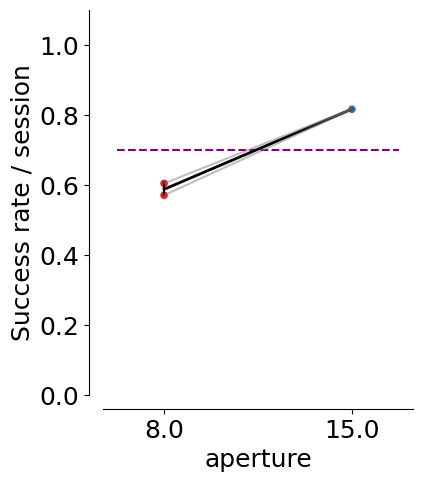

In [11]:
fig,ax = plt.subplots(1,1, figsize = (4,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,1.1)
sns.despine(offset=10)
plt.savefig(fig_save_path + "shape_occluder_rewards.svg", transparent=True)

0.41228405686237013 0.0736597182380315


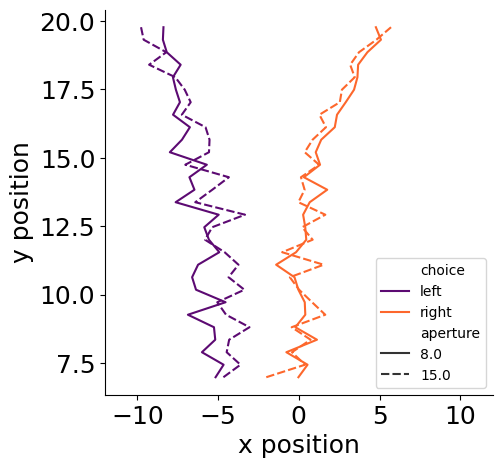

In [15]:
j_shaped = get_j_shaped(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")
mean_mouse = j_shaped.groupby(
    ["session","mouse_name", "date","dataset", "choice", "aperture", "trial", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()
mean_mouse = mean_mouse [mean_mouse.trial_rewarded > .5]
mean_mouse = mean_mouse.groupby(
    ["session","mouse_name", "date","dataset", "choice", "aperture",  "bin_centers"], as_index=False
).mean(numeric_only =True).copy()


fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse[mean_mouse.session == mean_mouse.session.unique() [1]],
    x="bin_centers",
    y="x",
    hue="choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-12,12)
plt.savefig(fig_save_path + "shape_dual_occluder_aperture_mean_traj.svg", transparent=True)

In [ ]:
sns.lineplot(data=big_df, )

In [16]:
mean_mouse = j_shaped.groupby(
    ["session","mouse_name", "date","dataset", "choice", "aperture", "trial",], as_index=False
).mean(numeric_only =True).copy()

In [49]:
def get_j_shaped(big_df, trial_tort_thresh=10):
        # J-shaped trials
    j_shaped = big_df[
        (big_df.trial_duration <= 5) & (big_df.trial_rewarded > 0.5) & (big_df["trial_tortuosity"] <= trial_tort_thresh)
    ]

    # stats: percentage of j shaped trials per session
    j_shaped_percentage = (
        j_shaped.groupby(["session"]).trial.nunique().values
        / big_df.groupby(["session"]).trial.nunique().values
    )
    print(j_shaped_percentage.mean(), stats.sem(j_shaped_percentage))
    return(j_shaped)


0.6667622872442149 0.015968636450564178


Text(0.5, 1.0, 'Unoccluded - 15.0')

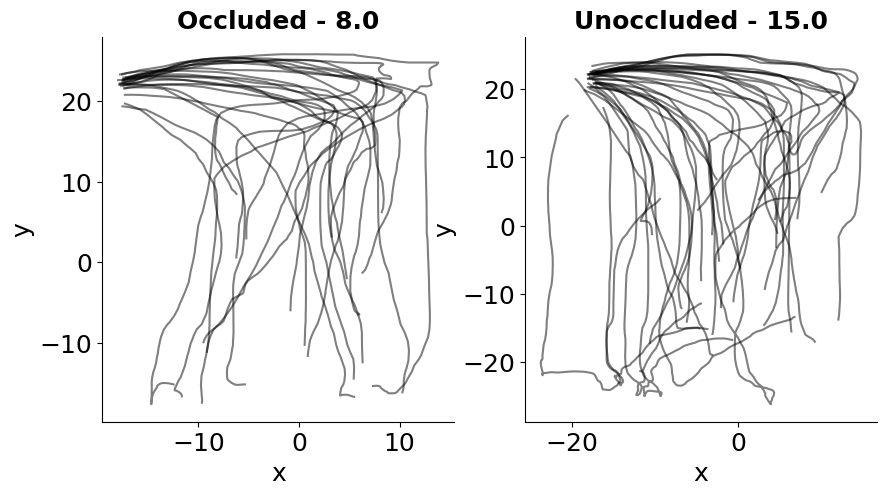

In [55]:
fig,ax = plt.subplots(1,2, figsize=(10,5))
j_shaped = get_j_shaped(big_df, trial_tort_thresh=25)
j_shaped = j_shaped [j_shaped.trial_left_choice == 1]
sns.lineplot(data= j_shaped [(j_shaped.session == j_shaped.session.unique()[0]) & (j_shaped.aperture == j_shaped.aperture.unique() [0])], x="x", y="y", units= "trial", color="black", alpha=0.5, estimator =None, sort=False, ax=ax[0])
ax[0].set_title(f"Occluded - {j_shaped.aperture.unique() [0]}")
sns.lineplot(data= j_shaped [(j_shaped.session == j_shaped.session.unique()[0]) & (j_shaped.aperture == j_shaped.aperture.unique() [1])], x="x", y="y", units= "trial", color="black", alpha=0.5, estimator =None, sort=False,ax=ax[1])
ax[1].set_title(f"Unoccluded - {j_shaped.aperture.unique() [1]}")

In [52]:
j_shaped.keys()

Index(['index', 'dataset', 'step', 'step_time', 'trial', 'reward', 'x', 'y',
       'bins_y', 'norm_y', 'mouse_can_report', 'iti', 'mouse_correct',
       'object_on_left', 'mouse_in_left', 'mouse_in_right', 'velocity',
       'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y',
       'head_dir', 'trial_duration', 'distance', 'trial_traj_path_length',
       'trial_init_x', 'trial_init_y', 'trial_end_x', 'trial_end_y',
       'trial_rewarded', 'trial_direct_path', 'trial_tortuosity', 'trial_step',
       'trial_step_time', 'trial_step_fraction', 'choice', 'flip_one_side',
       'trial_right_choice', 'trial_left_choice', 'aperture', 'time',
       'time_elapsed', 'mouse_name', 'session', 'date', 'training_stage',
       'session_increment', 'norm_x', 'distance_to_reward'],
      dtype='object')

In [ ]:
sns.lineplot(data= j_shaped [(j_shaped.session == j_shaped.session.unique()[1]]), x="x", y="y", hue = "aperture", units= "trial", estimator =None, sort=False)